In [1]:
import pandas as pd
import numpy as np
import os
from pathlib import Path
from dotenv import load_dotenv

## Load configuration

In [2]:
# Load env path
ENV_PATH = Path.cwd().parent / ".env"
load_dotenv(dotenv_path=ENV_PATH)

# Connect to database
POSTGRES_USER = os.getenv("POSTGRES_USER")
POSTGRES_PASSWORD = os.getenv("POSTGRES_PASSWORD")
POSTGRES_DB = os.getenv("POSTGRES_DB")
POSTGRES_HOST = os.getenv("POSTGRES_HOST")
POSTGRES_PORT = os.getenv("POSTGRES_PORT")

## Load database

In [3]:
from sqlalchemy import create_engine, text

# Create a connection to the PostgreSQL database
def get_db_dataframe():
    try:
        engine = create_engine(f"postgresql://{POSTGRES_USER}:{POSTGRES_PASSWORD}@{POSTGRES_HOST}:{POSTGRES_PORT}/{POSTGRES_DB}")

        # Read database from query
        df = pd.read_sql_query("SELECT * FROM engineering.supermarket;", engine)
        return df
    
    except Exception as e:
        print(f"Error connecting to the database: {e}")
        return None
    
# Read database
pd.set_option('display.max_columns', None)
df = get_db_dataframe()
df

Error connecting to the database: (psycopg2.OperationalError) connection to server at "localhost" (::1), port 5432 failed: Connection refused
	Is the server running on that host and accepting TCP/IP connections?
connection to server at "localhost" (127.0.0.1), port 5432 failed: Connection refused
	Is the server running on that host and accepting TCP/IP connections?

(Background on this error at: https://sqlalche.me/e/20/e3q8)


In [4]:
DB = Path.cwd().parent / "app" / "data" / "cleaned" / "sql_supermarket.parquet"
df = pd.read_parquet(DB)
df

,id,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,unit_price,profit_margin
0,1,AG-2011-2040,2011-01-01,2011-06-01,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",4080000.0,2,0.0,1061400.0,354600.0,Medium,2011,2040000.0,0.26
1,2,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",1200000.0,3,0.1,360360.0,97200.0,Medium,2011,400000.0,0.30
2,3,HU-2011-1220,2011-01-01,2011-05-01,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",660000.0,4,0.0,296400.0,81700.0,High,2011,165000.0,0.45
3,4,IT-2011-3647632,2011-01-01,2011-05-01,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",450000.0,3,0.5,-260550.0,48200.0,High,2011,150000.0,-0.58
4,5,CA-2011-1510,2011-02-01,2011-06-01,Standard Class,Magdelene Morse,Consumer,Ontario,Canada,Canada,Canada,TEC-OKI-10002750,Technology,Machines,"Okidata Inkjet, Wireless",3140000.0,1,0.0,31200.0,241000.0,Medium,2011,3140000.0,0.01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25030,25031,CA-2014-115427,2014-12-12,2015-04-01,Standard Class,Erica Bern,Corporate,California,United States,US,West,OFF-BI-10004632,Office Supplies,Binders,GBC Binding covers,210000.0,2,0.2,64750.0,20600.0,Medium,2014,105000.0,0.31
25031,25032,UP-2014-4410,2014-12-12,2015-04-01,Standard Class,Guy Thornton,Consumer,Zaporizhzhya,Ukraine,EMEA,EMEA,OFF-AVE-10003558,Office Supplies,Labels,"Avery Round Labels, Alphabetical",280000.0,4,0.0,61200.0,17000.0,Medium,2014,70000.0,0.22
25032,25033,MX-2014-108574,2014-12-12,2015-04-01,Standard Class,Julia Barnett,Home Office,Tamaulipas,Mexico,LATAM,North,OFF-LA-10004969,Office Supplies,Labels,"Novimex Legal Exhibit Labels, Adjustable",170000.0,3,0.0,6600.0,13200.0,Medium,2014,56700.0,0.04
25033,25034,MO-2014-2560,2014-12-12,2015-05-01,Standard Class,Liz Preis,Consumer,Souss-Massa-Draâ,Morocco,Africa,Africa,OFF-WIL-10001069,Office Supplies,Binders,"Wilson Jones Hole Reinforcements, Clear",40000.0,1,0.0,4200.0,4900.0,Medium,2014,40000.0,0.10


In [5]:
# Check data duplicate on subset order_id
df.duplicated(subset=['order_id']).sum()

0

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25035 entries, 0 to 25034
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id              25035 non-null  int64         
 1   order_id        25035 non-null  object        
 2   order_date      25035 non-null  datetime64[ns]
 3   ship_date       25035 non-null  datetime64[ns]
 4   ship_mode       25035 non-null  object        
 5   customer_name   25035 non-null  object        
 6   segment         25035 non-null  object        
 7   state           25035 non-null  object        
 8   country         25035 non-null  object        
 9   market          25035 non-null  object        
 10  region          25035 non-null  object        
 11  product_id      25035 non-null  object        
 12  category        25035 non-null  object        
 13  sub_category    25035 non-null  object        
 14  product_name    25035 non-null  object        
 15  sa

## Feature engineering

In [7]:
# Calculate underlying helper metrics to ensure feature engineering
df['order_date'] = pd.to_datetime(df['order_date'])
df['ship_date'] = pd.to_datetime(df['ship_date'])
df['shipping_days'] = (df['ship_date'] -  df['order_date']).dt.days

# Define a function to calculate fraud condition on column factors
condition_massive_loss = (df['discount'] >= 0.4) & (df['profit_margin'] <= -0.8)
condition_bulk_anomaly = (df['quantity'] > df['quantity'].quantile(0.99)) & (df['profit'] < 0)
condition_shipping_error = df['shipping_days'] < 0

In [8]:
df['profit_margin'].describe()

count    25035.000000
mean         0.033183
std          0.464471
min         -3.880000
25%         -0.020000
50%          0.150000
75%          0.320000
max          0.580000
Name: profit_margin, dtype: float64

In [9]:
# Combine condition to create the binary fraud label
df['fraud'] = np.where(condition_massive_loss | condition_bulk_anomaly | condition_shipping_error, 1, 0)
print(df["fraud"].value_counts(normalize=True))

fraud
0    0.660116
1    0.339884
Name: proportion, dtype: float64


## Data is clean

In [20]:
df.head()

,id,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,unit_price,profit_margin,shipping_days,fraud
0,1,AG-2011-2040,2011-01-01,2011-06-01,Standard Class,Toby Braunhardt,Consumer,Constantine,Algeria,Africa,Africa,OFF-TEN-10000025,Office Supplies,Storage,"Tenex Lockers, Blue",4080000.0,2,0.0,1061400.0,354600.0,Medium,2011,2040000.0,0.26,151,0
1,2,IN-2011-47883,2011-01-01,2011-08-01,Standard Class,Joseph Holt,Consumer,New South Wales,Australia,APAC,Oceania,OFF-SU-10000618,Office Supplies,Supplies,"Acme Trimmer, High Speed",1200000.0,3,0.1,360360.0,97200.0,Medium,2011,400000.0,0.30,212,0
2,3,HU-2011-1220,2011-01-01,2011-05-01,Second Class,Annie Thurman,Consumer,Budapest,Hungary,EMEA,EMEA,OFF-TEN-10001585,Office Supplies,Storage,"Tenex Box, Single Width",660000.0,4,0.0,296400.0,81700.0,High,2011,165000.0,0.45,120,0
3,4,IT-2011-3647632,2011-01-01,2011-05-01,Second Class,Eugene Moren,Home Office,Stockholm,Sweden,EU,North,OFF-PA-10001492,Office Supplies,Paper,"Enermax Note Cards, Premium",450000.0,3,0.5,-260550.0,48200.0,High,2011,150000.0,-0.58,120,0
4,5,CA-2011-1510,2011-02-01,2011-06-01,Standard Class,Magdelene Morse,Consumer,Ontario,Canada,Canada,Canada,TEC-OKI-10002750,Technology,Machines,"Okidata Inkjet, Wireless",3140000.0,1,0.0,31200.0,241000.0,Medium,2011,3140000.0,0.01,120,0


## Data encoding

In [11]:
df_encode = df.copy()

# Encode the data using label encoding for categorical features
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
cat_cols = df_encode.select_dtypes(include=['object']).columns

for col in cat_cols:
    df_encode[col] = le.fit_transform(df_encode[col])

# Check the first few rows of the encoded features
df_encode.head()

,id,order_id,order_date,ship_date,ship_mode,customer_name,segment,state,country,market,region,product_id,category,sub_category,product_name,sales,quantity,discount,profit,shipping_cost,order_priority,year,unit_price,profit_margin,shipping_days,fraud
0,1,9,2011-01-01,2011-06-01,3,751,0,255,2,1,0,6624,1,14,3266,4080000.0,2,0.0,1061400.0,354600.0,3,2011,2040000.0,0.26,151,0
1,2,10995,2011-01-01,2011-08-01,3,398,0,701,6,0,9,6321,1,15,154,1200000.0,3,0.1,360360.0,97200.0,3,2011,400000.0,0.30,212,0
2,3,9012,2011-01-01,2011-05-01,2,48,0,175,56,3,5,6636,1,14,3235,660000.0,4,0.0,296400.0,81700.0,1,2011,165000.0,0.45,120,0
3,4,14939,2011-01-01,2011-05-01,2,275,2,937,123,4,7,5222,1,12,1253,450000.0,3,0.5,-260550.0,48200.0,1,2011,150000.0,-0.58,120,0
4,5,942,2011-02-01,2011-06-01,3,483,0,746,22,2,1,8185,2,11,2541,3140000.0,1,0.0,31200.0,241000.0,3,2011,3140000.0,0.01,120,0


## Split data into X and y

In [12]:
from sklearn.model_selection import train_test_split
X = df_encode.drop(columns=['fraud', 'order_id', 'order_date', 'ship_date', 'product_id', 'id'])
y = df_encode['fraud']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Data after split:")
print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")

Data after split:
Training set size: 20028
Test set size: 5007


## Data visualization

In [13]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 8))
plt.bar(['Not Fraud', 'Fraud'], df['fraud'].value_counts(), color=['blue', 'red'])
plt.title('Fraud vs Not Fraud Distribution')
plt.xlabel('Fraud Label')
plt.ylabel('Count')
plt.show()

KeyboardInterrupt: 

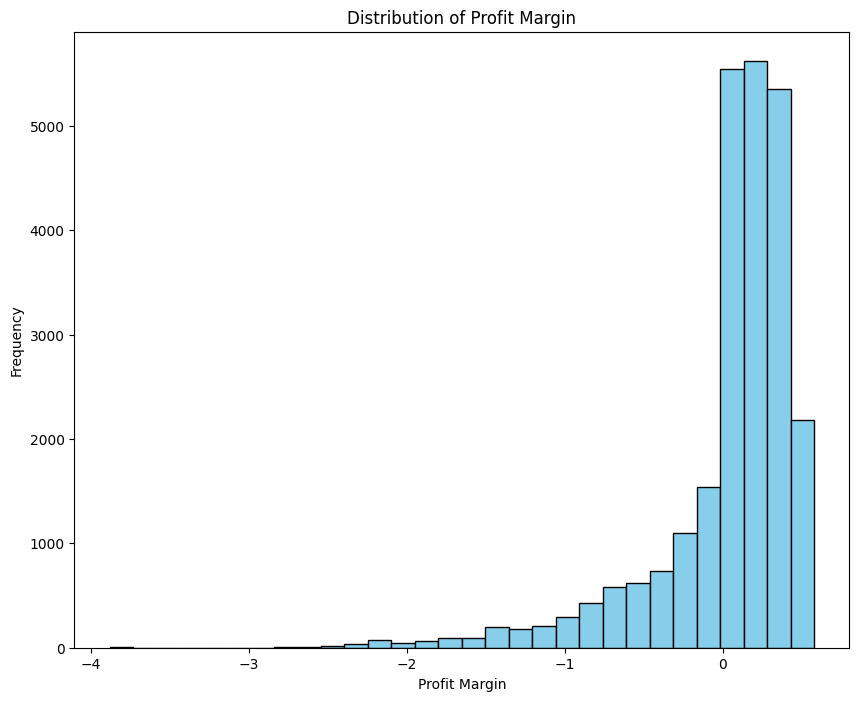

In [ ]:
# Check distribution of profit_margin
plt.figure(figsize=(10, 8))
plt.hist(df['profit_margin'], bins=30, color='skyblue', edgecolor='black')
plt.title('Distribution of Profit Margin')
plt.xlabel('Profit Margin')
plt.ylabel('Frequency')
plt.show()

In [ ]:
y.value_counts()

fraud
0    16526
1     8509
Name: count, dtype: int64

In [ ]:
X_test.select_dtypes(include=['object']).columns

Index([], dtype='object')

## Machine learning models

In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

# Define models
models = {
    "RandomForestClassifier": RandomForestClassifier(random_state=42),
    "GradientBoostingClassifier": GradientBoostingClassifier(random_state=42),
    "XGBClassifier": XGBClassifier(random_state=42)
}

# Define params
params_randomized = {
    "RandomForestClassifier": {
        "n_estimators": [100, 200],
        "max_depth": [10, 20],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
    },
    "GradientBoostingClassifier": {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 5, 7],
    },
    "XGBClassifier": {
        "n_estimators": [100, 200],
        "learning_rate": [0.01, 0.1, 0.2],
        "max_depth": [3, 5, 7],
    }
}

# Train and evaluate models
trained_models = {}
results = []

for model_name, model in models.items():
    print("=" * 70)
    print(f"Training {model_name}")

    # Perform RandomizedSearchCV
    random_search = RandomizedSearchCV(
        estimator=model,
        param_distributions=params_randomized[model_name],
        n_iter=10,
        scoring='f1',
        cv=5,
        verbose=1,
        random_state=42,
        n_jobs=-1
    )

    # Fit the model
    random_search.fit(X_train, y_train)

    # Get the best model
    best_model = random_search.best_estimator_

    # Store the trained model
    trained_models[model_name] = best_model

    # Get the best parameters
    print(f"Best parameters for {model_name}: {random_search.best_params_}")

    # Predict on test set
    y_pred = best_model.predict(X_test)

    # Calculate metrics
    from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, precision_score, recall_score
    f1 = f1_score(y_test, y_pred)
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)

    # Append results to the list
    results.append({
        "model": model_name,
        "f1_score": f1,
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall
    })

# Convert results to DataFrame for better visualization and sort by f1_score
df_results = pd.DataFrame(results).sort_values(by='f1_score', ascending=False).reset_index(drop=True)
print("\n=== Model Comparison Results ===")
display(df_results)

import joblib

NOTEBOOK_DIR = Path(os.getcwd())
TARGET_MODELS_DIR = NOTEBOOK_DIR.parent / "Models" / "fraud_ml_models"

# Save metrics table to csv file
metrics_filename = "model_comparison_results.csv"
df_results.to_csv(metrics_filename, index=False)
print(f"\n📊 Metrics table successfully saved to '{metrics_filename}'")

# Save each trained models
print("\n💾 Saving trained models...")
for model_name, trained_model in trained_models.items():

    save_path = TARGET_MODELS_DIR / f"{model_name}.pkl"    
    joblib.dump(trained_model, save_path)
    print(f"✅ {model_name} successfully synced and saved to '{save_path}'")

Training RandomForestClassifier
Fitting 5 folds for each of 10 candidates, totalling 50 fits


Best parameters for RandomForestClassifier: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 20}
Training GradientBoostingClassifier
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters for GradientBoostingClassifier: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.2}
Training XGBClassifier
Fitting 5 folds for each of 10 candidates, totalling 50 fits
Best parameters for XGBClassifier: {'n_estimators': 200, 'max_depth': 5, 'learning_rate': 0.01}

=== Model Comparison Results ===


,model,f1_score,accuracy,precision,recall
0,GradientBoostingClassifier,1.000000,1.000000,1.000000,1.00000
1,XGBClassifier,0.998826,0.999201,0.997655,1.00000
2,RandomForestClassifier,0.998824,0.999201,1.000000,0.99765



📊 Metrics table successfully saved to 'model_comparison_results.csv'

💾 Saving trained models...
✅ RandomForestClassifier successfully synced and saved to '/Users/miftahhadiyannoor/Documents/Supermarket_Sales/Production/Models/fraud_ml_models/RandomForestClassifier.pkl'
✅ GradientBoostingClassifier successfully synced and saved to '/Users/miftahhadiyannoor/Documents/Supermarket_Sales/Production/Models/fraud_ml_models/GradientBoostingClassifier.pkl'
✅ XGBClassifier successfully synced and saved to '/Users/miftahhadiyannoor/Documents/Supermarket_Sales/Production/Models/fraud_ml_models/XGBClassifier.pkl'


In [ ]:
# Verify models after saving
from sklearn.utils.validation import check_is_fitted

for model_name, trained_model in trained_models.items():
    try:
        check_is_fitted(trained_model)
        print(f"✅ {model_name} is fitted and ready for use.")
    except Exception as e:
        print(f"❌ {model_name} is not fitted: {e}")

✅ RandomForestClassifier is fitted and ready for use.
✅ GradientBoostingClassifier is fitted and ready for use.
✅ XGBClassifier is fitted and ready for use.
